# nnU-Net: GGO Segmentation on RexGrounding-CT

This notebook covers:
1. Environment setup and variable configuration
2. Dataset conversion from RexGrounding-CT format → nnU-Net format
3. Dataset fingerprinting and preprocessing
4. Model training (all folds)
5. Finding the best configuration
6. Inference and postprocessing

---
**Dataset specifics handled here:**
- Multi-finding masks (FxHxWxD) — only GGO channels extracted
- Instance-coded mask values → binary semantic mask (0/1)
- Variable depth (D: 104–1005 slices)
- HU-valued CT volumes
- JSON-driven train/valid/test splits

## 0. Install dependencies

Install dependencies in the terminal

```
uv venv --python 3.12.12
source .venv/bin/activate
uv add torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
uv add nnunetv2
```

Optional: network topology visualisation
pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git

In [8]:
# Install dependencies in the terminal

# uv venv --python 3.12.12
# source .venv/bin/activate
# uv add tqdm nibabel numpy matplotlib
# uv add torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu132
# uv add nnunetv2cleare

# Optional: network topology visualisation
# pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git

## 1. Configuration — edit these paths before running anything else

In [9]:
import os
import pathlib

# ------------------------------------------------------------------ #
#  EDIT THESE                                                        #
# ------------------------------------------------------------------ #

# Path to the JSON split file produced for GGO
SPLIT_JSON = r"/home/chest_ct/code/data/rexgrounding-ct/dataset_4_ggo_2c_img_processing.json"

# Root directories where raw data already lives
# (these are read-only; nnU-Net gets its own copy)
CT_ROOT    = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed"  # parent of train_XXX folders
SEG_ROOT   = r"/home/chest_ct/code/data/segmentations/segmentations"        # flat folder of *_seg.nii.gz

# nnU-Net storage locations (will be created if absent)
NNUNET_RAW          = r"/home/chest_ct/code/models/nnu-net/storage/nnUNet_raw"
NNUNET_PREPROCESSED = r"/home/chest_ct/code/models/nnu-net/storage/nnUNet_preprocessed"
NNUNET_RESULTS      = r"/home/chest_ct/code/models/nnu-net/storage/nnUNet_results"

# Dataset identity
DATASET_ID   = 100          # you can use any 3-digit integer
DATASET_NAME = "GGO"        # short label, no spaces

# Training
CONFIGURATION = "3d_fullres" # or "3d_lowres"
N_FOLDS       = 5
CUDA_DEVICE   = 0            # GPU index; ignored when device="cpu"

# ------------------------------------------------------------------ #

DATASET_FULL_NAME = f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
DATASET_RAW_DIR   = os.path.join(NNUNET_RAW, DATASET_FULL_NAME)

for d in [NNUNET_RAW, NNUNET_PREPROCESSED, NNUNET_RESULTS]:
    os.makedirs(d, exist_ok=True)

# Set environment variables for the current process and all child processes
os.environ["nnUNet_raw"]          = NNUNET_RAW
os.environ["nnUNet_preprocessed"] = NNUNET_PREPROCESSED
os.environ["nnUNet_results"]      = NNUNET_RESULTS

print("Dataset folder:", DATASET_RAW_DIR)
print("Environment variables set.")

Dataset folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset100_GGO
Environment variables set.


## 2. Convert RexGrounding-CT → nnU-Net format

### Key design decisions

| Question | Choice |
|---|---|
| Which mask channels to use? | Only `ggo_channels` listed in the JSON |
| Instance values → semantic? | Any non-zero pixel in any GGO channel becomes label `1` |
| Multi-finding overlap? | Union — a voxel active in *any* GGO channel is foreground |
| Modality string | `CT` (nnU-Net applies HU-aware normalisation automatically) |
| File suffix | `.nii.gz` (NibabelIO) |
| Case identifier | Stem of the volume filename, e.g. `train_298_a_2` |

In [10]:
import json
import shutil
from pathlib import Path
import numpy as np
import nibabel as nib
from tqdm.auto import tqdm


def extract_ggo_mask(seg_path: str, ggo_channels: list[int]) -> np.ndarray:
    """
    Load a multi-finding mask (F x H x W x D) and collapse the GGO
    channels into a single binary semantic mask (H x W x D).

    Background = 0, GGO foreground = 1.
    Instance labels (>0) in any GGO channel are all treated as foreground.
    """
    img  = nib.load(seg_path)
    data = img.get_fdata(dtype=np.float32)  # shape: F x H x W x D  (or H x W x D if F=1)

    if data.ndim == 3:
        # Single-channel mask stored without F dimension
        data = data[np.newaxis, ...]  # -> 1 x H x W x D

    # Union of all requested GGO channels
    binary = np.zeros(data.shape[1:], dtype=np.uint8)  # H x W x D
    for ch in ggo_channels:
        if ch < data.shape[0]:
            binary = np.logical_or(binary, data[ch] > 0).astype(np.uint8)

    return binary, img.affine, img.header


def resolve_local_paths(raw_name: str) -> tuple[Path, Path]:
    """Build Linux paths from the case filename; JSON paths are Windows paths."""
    case_id = raw_name.replace(".nii.gz", "")
    parts = case_id.split("_")
    train_dir = "_".join(parts[:2])          # e.g. train_298
    series_dir = "_".join(parts[:-1])        # e.g. train_298_a
    ct_path = Path(CT_ROOT) / train_dir / series_dir / raw_name
    seg_path = Path(SEG_ROOT) / raw_name
    return ct_path, seg_path


def convert_split(
    entries: list[dict],
    images_out: Path,
    labels_out: Path,
    desc: str = "Converting",
    skip_missing: bool = True,
) -> list[str]:
    """
    Convert a list of dataset entries.
    Returns the list of case identifiers that were successfully converted.
    """
    images_out.mkdir(parents=True, exist_ok=True)
    labels_out.mkdir(parents=True, exist_ok=True)

    case_ids = []
    for entry in tqdm(entries, desc=desc):
        raw_name  = entry["name"]                     # e.g. "train_298_a_2.nii.gz"
        case_id   = raw_name.replace(".nii.gz", "")   # e.g. "train_298_a_2"
        ct_path, seg_path = resolve_local_paths(raw_name)
        ggo_chs   = entry["ggo_channels"]

        if not os.path.isfile(ct_path):
            if skip_missing:
                print(f"  [SKIP] CT not found: {ct_path}")
                continue
            raise FileNotFoundError(ct_path)

        if not os.path.isfile(seg_path):
            if skip_missing:
                print(f"  [SKIP] Seg not found: {seg_path}")
                continue
            raise FileNotFoundError(seg_path)

        # --- Copy CT image ---
        # nnU-Net requires suffix _XXXX.nii.gz for the channel index (0000 = first/only modality)
        ct_dest = images_out / f"{case_id}_0000.nii.gz"
        if not ct_dest.exists():
            shutil.copy2(ct_path, ct_dest)

        # --- Build binary GGO label ---
        # The RexGrounding segmentation files can have placeholder geometry
        # (for example spacing 1,1,1), so write labels with CT geometry.
        lbl_dest = labels_out / f"{case_id}.nii.gz"
        binary, _, _ = extract_ggo_mask(seg_path, ggo_chs)
        ct_img = nib.load(str(ct_dest))
        if binary.shape != ct_img.shape:
            raise ValueError(f"Shape mismatch for {case_id}: CT {ct_img.shape}, label {binary.shape}")
        lbl_header = ct_img.header.copy()
        lbl_img = nib.Nifti1Image(binary.astype(np.uint8), ct_img.affine, lbl_header)
        lbl_img.set_data_dtype(np.uint8)
        nib.save(lbl_img, str(lbl_dest))

        case_ids.append(case_id)

    return case_ids


# ── Load split JSON ────────────────────────────────────────────────
with open(SPLIT_JSON) as f:
    split_data = json.load(f)

val_entries = split_data.get("valid", []) + split_data.get("val", [])

print(f"Train : {len(split_data.get('train', []))} cases")
print(f"Valid : {len(val_entries)} cases")
print(f"Test  : {len(split_data.get('test',  []))} cases")

Train : 742 cases
Valid : 14 cases
Test  : 21 cases


In [11]:
# ── Convert training + validation (both go into imagesTr / labelsTr) ──
# nnU-Net manages its own CV splits, so train+valid are merged here.
# Test images go into imagesTs (no labels required).

images_tr = Path(DATASET_RAW_DIR) / "imagesTr"
labels_tr = Path(DATASET_RAW_DIR) / "labelsTr"
images_ts = Path(DATASET_RAW_DIR) / "imagesTs"

train_cases = convert_split(
    split_data.get("train", []) + val_entries,
    images_tr, labels_tr,
    desc="Train+Valid",
)

# Test split: images only (labels not needed for inference)
test_entries = split_data.get("test", [])
if test_entries:
    images_ts.mkdir(parents=True, exist_ok=True)
    for entry in tqdm(test_entries, desc="Test images"):
        case_id  = entry["name"].replace(".nii.gz", "")
        ct_path, _ = resolve_local_paths(entry["name"])
        ct_dest  = images_ts / f"{case_id}_0000.nii.gz"
        if os.path.isfile(ct_path) and not ct_dest.exists():
            shutil.copy2(ct_path, ct_dest)

print(f"\nConversion complete.")
print(f"  Training cases : {len(train_cases)}")
print(f"  Test images    : {len(test_entries)}")

Train+Valid:   0%|          | 0/756 [00:00<?, ?it/s]

  [SKIP] CT not found: /home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_5700/train_5700_a/train_5700_a_2.nii.gz
  [SKIP] CT not found: /home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_12505/train_12505_a/train_12505_a_1.nii.gz
  [SKIP] CT not found: /home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_12643/train_12643_a/train_12643_a_1.nii.gz
  [SKIP] CT not found: /home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_12915/train_12915_b/train_12915_b_2.nii.gz
  [SKIP] CT not found: /home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_10314/train_10314_a/train_10314_a_1.nii.gz
  [SKIP] CT not found: /home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_10125/train_10125_a/train_10125_a_1.nii.gz
  [SKIP] CT not found: /home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_11262/train_11262_a/train_11262_a_1.nii.gz
  [SKIP] CT not found: /home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_12470/

Test images:   0%|          | 0/21 [00:00<?, ?it/s]


Conversion complete.
  Training cases : 538
  Test images    : 21


In [12]:
# ── Write dataset.json ─────────────────────────────────────────────
# nnU-Net v2 requires this file in the dataset root.

from nnunetv2.dataset_conversion.generate_dataset_json import generate_dataset_json

generate_dataset_json(
    output_folder   = DATASET_RAW_DIR,
    channel_names   = {0: "CT"},     # single CT modality; nnU-Net will use CT-specific normalisation
    labels          = {"background": 0, "GGO": 1},
    num_training_cases = len(train_cases),
    file_ending     = ".nii.gz",
    dataset_name    = DATASET_FULL_NAME,
    reference       = "RexGrounding-CT",
    description     = "Binary GGO segmentation extracted from multi-finding RexGrounding-CT masks",
)

print("dataset.json written to:", DATASET_RAW_DIR)

dataset.json written to: /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset100_GGO


In [13]:
# ── Sanity-check: inspect a single converted case ──────────────────
import nibabel as nib
import numpy as np

sample_case = train_cases[0]
ct_img  = nib.load(str(images_tr / f"{sample_case}_0000.nii.gz"))
lbl_img = nib.load(str(labels_tr / f"{sample_case}.nii.gz"))

ct_arr  = ct_img.get_fdata()
lbl_arr = lbl_img.get_fdata()

print(f"Case : {sample_case}")
print(f"CT   shape : {ct_arr.shape}  | dtype: {ct_arr.dtype}")
print(f"Label shape: {lbl_arr.shape} | dtype: {lbl_arr.dtype}")
print(f"CT HU range: [{ct_arr.min():.0f}, {ct_arr.max():.0f}]")
print(f"Label unique values: {np.unique(lbl_arr)}")
print(f"GGO voxel fraction : {lbl_arr.mean():.4%}")

assert ct_arr.shape == lbl_arr.shape, "Shape mismatch between CT and label!"
print("\n✓ Shapes match.")

Case : train_2239_a_2
CT   shape : (512, 512, 412)  | dtype: float64
Label shape: (512, 512, 412) | dtype: float64
CT HU range: [-1024, 3071]
Label unique values: [0. 1.]
GGO voxel fraction : 0.3659%

✓ Shapes match.


## 3. Plan and preprocess

This extracts the dataset fingerprint, automatically selects patch sizes / batch sizes / normalisation, and writes preprocessed data to `nnUNet_preprocessed`.

> **Runtime:** expect 10–60 min depending on the number of cases and disk speed.

In [14]:
# Verify integrity and run plan+preprocess in one step.
# This cell reports preprocessing status. It does not auto-run preprocessing
# during "Run All" because nnU-Net deletes/rebuilds the preprocessed folder.
import pathlib

AUTO_RUN_PREPROCESSING = False

plans_path = pathlib.Path(NNUNET_PREPROCESSED) / DATASET_FULL_NAME / "nnUNetPlans.json"
preproc_root = pathlib.Path(NNUNET_PREPROCESSED) / DATASET_FULL_NAME
fullres_dir = preproc_root / "nnUNetPlans_3d_fullres"
twod_dir = preproc_root / "nnUNetPlans_2d"

fullres_files = len(list(fullres_dir.glob("*"))) if fullres_dir.exists() else 0
twod_files = len(list(twod_dir.glob("*"))) if twod_dir.exists() else 0

print("Plans:", plans_path)
print("Plans exists:", plans_path.exists())
print("3d_fullres files:", fullres_files)
print("2d files:", twod_files)

preprocess_cmd = (
    f"nnUNetv2_plan_and_preprocess -d {DATASET_ID} "
    f"--verify_dataset_integrity -c 3d_fullres 2d -np 2 2 --no_pbar"
)

if plans_path.exists() and fullres_files >= 120 and twod_files >= 120:
    print("Preprocessing already complete; skipping nnUNetv2_plan_and_preprocess.")
elif AUTO_RUN_PREPROCESSING:
    print("Preprocessing outputs are missing/incomplete; running:")
    print(preprocess_cmd)
    !nnUNetv2_plan_and_preprocess \
        -d {DATASET_ID} \
        --verify_dataset_integrity \
        -c 3d_fullres 2d \
        -np 2 2 \
        --no_pbar
else:
    print("Preprocessing outputs are missing/incomplete, but AUTO_RUN_PREPROCESSING is False.")
    print("Run this manually if needed:")
    print(" ", preprocess_cmd)


Plans: /home/chest_ct/code/models/nnu-net/storage/nnUNet_preprocessed/Dataset100_GGO/nnUNetPlans.json
Plans exists: True
3d_fullres files: 120
2d files: 120
Preprocessing already complete; skipping nnUNetv2_plan_and_preprocess.


In [15]:
# Inspect what was planned
import json
import pathlib

plans_path = pathlib.Path(NNUNET_PREPROCESSED) / DATASET_FULL_NAME / "nnUNetPlans.json"
with open(plans_path) as f:
    plans = json.load(f)

for cfg_name, cfg in plans["configurations"].items():
    print(f"\n── {cfg_name} ─────────────────────")
    print(f"  patch_size          : {cfg.get('patch_size')}")
    print(f"  batch_size          : {cfg.get('batch_size')}")
    print(f"  normalization       : {cfg.get('normalization_schemes')}")
    print(f"  spacing             : {cfg.get('spacing')}")


── 2d ─────────────────────
  patch_size          : [640, 640]
  batch_size          : 8
  normalization       : ['CTNormalization']
  spacing             : [0.6962890625, 0.6962890625]

── 3d_lowres ─────────────────────
  patch_size          : [96, 160, 160]
  batch_size          : 2
  normalization       : ['CTNormalization']
  spacing             : [2.1565912675438432, 1.501610911873789, 1.501610911873789]

── 3d_fullres ─────────────────────
  patch_size          : [96, 160, 160]
  batch_size          : 2
  normalization       : ['CTNormalization']
  spacing             : [1.0, 0.6962890625, 0.6962890625]

── 3d_cascade_fullres ─────────────────────
  patch_size          : None
  batch_size          : None
  normalization       : None
  spacing             : None


## 4. Train — 5-fold cross-validation

Each fold takes several hours on a modern GPU. Run folds in parallel across multiple GPUs by opening separate terminals (or Jupyter kernels) and setting `CUDA_VISIBLE_DEVICES` for each.

`--npz` saves validation softmax probabilities — **required** for `nnUNetv2_find_best_configuration`.

In [16]:
# ── Safe training launcher ─────────────────────────────────────────
# Full 5-fold training takes ~31 hours on this machine. This cell does NOT
# auto-start long training when "Run All" is used.
#
# To train a shorter first model manually, copy one of the printed commands
# into a terminal.

TRAIN_FOLDS = [0, 1, 2, 3, 4]
SHORT_TRAINER = "nnUNetTrainer_250epochs"  # alternatives: nnUNetTrainer_100epochs, nnUNetTrainer_500epochs
AUTO_RUN_TRAINING = True

for fold in TRAIN_FOLDS:
    short_cmd = (
        f"CUDA_VISIBLE_DEVICES={CUDA_DEVICE} "
        f"nnUNetv2_train {DATASET_ID} {CONFIGURATION} {fold} "
        f"-tr {SHORT_TRAINER} --npz"
    )
    full_cmd = (
        f"CUDA_VISIBLE_DEVICES={CUDA_DEVICE} "
        f"nnUNetv2_train {DATASET_ID} {CONFIGURATION} {fold} --npz"
    )
    print(f"Fold {fold} short command:")
    print(" ", short_cmd)
    print(f"Fold {fold} full 1000-epoch command:")
    print(" ", full_cmd)

if AUTO_RUN_TRAINING:
    for fold in TRAIN_FOLDS:
        !CUDA_VISIBLE_DEVICES={CUDA_DEVICE} nnUNetv2_train \
            {DATASET_ID} {CONFIGURATION} {fold} \
            -tr {SHORT_TRAINER} \
            --npz
else:
    print("\nAUTO_RUN_TRAINING is False, so no training was started from this notebook run.")


Fold 0 short command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 0 -tr nnUNetTrainer_250epochs --npz
Fold 0 full 1000-epoch command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 0 --npz
Fold 1 short command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 1 -tr nnUNetTrainer_250epochs --npz
Fold 1 full 1000-epoch command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 1 --npz
Fold 2 short command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 2 -tr nnUNetTrainer_250epochs --npz
Fold 2 full 1000-epoch command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 2 --npz
Fold 3 short command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 3 -tr nnUNetTrainer_250epochs --npz
Fold 3 full 1000-epoch command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 3 --npz
Fold 4 short command:
  CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 4 -tr nnUNetTrainer_250epochs --npz
Fold 4 full 1000-epoch command:
  CUDA_VISIBLE_DEVICES=

In [26]:
# ── Commands for manual fold training ──────────────────────────────
print("Short 250-epoch commands:")
for fold in range(N_FOLDS):
    print(
        f"CUDA_VISIBLE_DEVICES={CUDA_DEVICE} "
        f"nnUNetv2_train {DATASET_ID} {CONFIGURATION} {fold} "
        f"-tr nnUNetTrainer_250epochs --npz"
    )

print("\nFull 1000-epoch commands:")
for fold in range(N_FOLDS):
    print(
        f"CUDA_VISIBLE_DEVICES={CUDA_DEVICE} "
        f"nnUNetv2_train {DATASET_ID} {CONFIGURATION} {fold} --npz"
    )


Short 250-epoch commands:
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 0 -tr nnUNetTrainer_250epochs --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 1 -tr nnUNetTrainer_250epochs --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 2 -tr nnUNetTrainer_250epochs --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 3 -tr nnUNetTrainer_250epochs --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 4 -tr nnUNetTrainer_250epochs --npz

Full 1000-epoch commands:
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 0 --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 1 --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 2 --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 3 --npz
CUDA_VISIBLE_DEVICES=0 nnUNetv2_train 100 3d_fullres 4 --npz


In [27]:
# ── Monitor training progress ──────────────────────────────────────
import json
import pathlib

results_root = pathlib.Path(NNUNET_RESULTS)

for fold in range(N_FOLDS):
    fold_dir = (
        results_root
        / DATASET_FULL_NAME
        / f"nnUNetTrainer__nnUNetPlans__{CONFIGURATION}"
        / f"fold_{fold}"
    )
    summary_path = fold_dir / "validation" / "summary.json"
    logs = sorted(fold_dir.glob("training_log_*.txt"))
    ckpt_best = fold_dir / "checkpoint_best.pth"
    ckpt_final = fold_dir / "checkpoint_final.pth"

    print(f"\nFold {fold}")
    print("  folder:", fold_dir)
    print("  checkpoint_best:", ckpt_best.exists())
    print("  checkpoint_final:", ckpt_final.exists())

    if summary_path.exists():
        with open(summary_path) as f:
            s = json.load(f)
        fg = s.get("foreground_mean", {})
        dice = fg.get("Dice", fg.get("dice", "N/A"))
        print(f"  Validation Dice (foreground mean): {dice}")
    elif logs:
        print("  summary.json not found; training is not complete.")
        print("  latest log:", logs[-1])
        tail_lines = logs[-1].read_text().splitlines()[-8:]
        for line in tail_lines:
            print("   ", line)
    else:
        print("  No training log found.")



Fold 0
  folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0
  checkpoint_best: True
  checkpoint_final: False
  summary.json not found; training is not complete.
  latest log: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/training_log_2026_6_5_10_37_45.txt
    2026-06-05 11:40:12.345874: Current learning rate: 0.00853 
    2026-06-05 11:40:34.894418: train_loss -0.7011 
    2026-06-05 11:40:34.894509: val_loss -0.1171 
    2026-06-05 11:40:34.894533: Pseudo dice [np.float32(0.174)] 
    2026-06-05 11:40:34.894561: Epoch time: 22.55 s 
    2026-06-05 11:40:35.541167:  
    2026-06-05 11:40:35.541271: Epoch 163 
    2026-06-05 11:40:35.541331: Current learning rate: 0.00852 

Fold 1
  folder: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_1
  checkpoint_best: False
  chec

## 5. Find the best configuration (optional but recommended)

In [30]:
# This compares completed trained configurations and writes inference_instructions.txt.
# It is skipped until at least one validation summary exists.
trainer_root = pathlib.Path(NNUNET_RESULTS) / DATASET_FULL_NAME
summaries = list(trainer_root.glob("**/validation/summary.json"))

if summaries:
    print(summaries)
    !nnUNetv2_find_best_configuration 100 \
    -c 3d_fullres \
    -tr nnUNetTrainer_250epochs \
    --disable_ensembling
else:
    print("No completed validation summaries found; skipping find_best_configuration.")




[PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/fold_2/validation/summary.json'), PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/fold_0/validation/summary.json'), PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/fold_3/validation/summary.json'), PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/fold_4/validation/summary.json'), PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/fold_1/validation/summary.json'), PosixPath('/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_3/validation/summary.json'), PosixPa

In [33]:
# Read the recommended inference command
instructions_path = pathlib.Path(NNUNET_RESULTS) / DATASET_FULL_NAME / "inference_instructions.txt"
if instructions_path.exists():
    print(instructions_path.read_text())
else:
    print("inference_instructions.txt not found — did find_best_configuration complete?")

***Run inference like this:***

nnUNetv2_predict -d Dataset100_GGO -i INPUT_FOLDER -o OUTPUT_FOLDER -f  0 1 2 3 4 -tr nnUNetTrainer_250epochs -c 3d_fullres -p nnUNetPlans

***Once inference is completed, run postprocessing like this:***

nnUNetv2_apply_postprocessing -i OUTPUT_FOLDER -o OUTPUT_FOLDER_PP -pp_pkl_file /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/crossval_results_folds_0_1_2_3_4/postprocessing.pkl -np 8 -plans_json /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/nnUNetTrainer_250epochs__nnUNetPlans__3d_fullres/crossval_results_folds_0_1_2_3_4/plans.json



## 6. Inference

Input images must follow the same naming convention used during training:
`<case_id>_0000.nii.gz`

In [32]:
# ── Define inference I/O ───────────────────────────────────────────
INFER_INPUT_FOLDER  = str(images_ts)   # imagesTs prepared during conversion
INFER_OUTPUT_FOLDER = os.path.join(NNUNET_RESULTS, DATASET_FULL_NAME, "predictions")

os.makedirs(INFER_OUTPUT_FOLDER, exist_ok=True)
print("Input :", INFER_INPUT_FOLDER)
print("Output:", INFER_OUTPUT_FOLDER)

Input : /home/chest_ct/code/models/nnu-net/storage/nnUNet_raw/Dataset100_GGO/imagesTs
Output: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/predictions


In [45]:
# ── Run inference ──────────────────────────────────────────────────
# This is skipped until a completed checkpoint exists.
trainer_root = pathlib.Path(NNUNET_RESULTS) / DATASET_FULL_NAME
completed = list(trainer_root.glob("**/checkpoint_final.pth"))

if completed:
    !nnUNetv2_predict -d {DATASET_ID} -i "{INFER_INPUT_FOLDER}" -o "{INFER_OUTPUT_FOLDER}" -f 0 1 2 3 4 -tr nnUNetTrainer_250epochs -c {CONFIGURATION}
else:
    print("No checkpoint_final.pth found; skipping inference.")
    print("Finish training first, then run this cell.")
    print("No checkpoint_final.pth found; skipping inference.")
    print("Finish training first, then run this cell.")



#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 64 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 64 cases that I would like to predict

Predicting train_2715_b_1:
perform_everything_on_device: True
100%|█████████████████████████████████████████| 180/180 [00:26<00:00,  6.79it/s]
sending off prediction to background worker for resampling and export
done with train_2715_b_1

Predicting train_2717_a_1:
perform_everything_on_device: True
100%|█████████████████████████████████████████| 216/216 [00:32<00:00,  6.72it/s]
sending off prediction to background worker for re

In [46]:
# ── Apply postprocessing (if find_best_configuration was run) ──────
trainer_folder = (
    pathlib.Path(NNUNET_RESULTS)
    / DATASET_FULL_NAME
    / f"nnUNetTrainer__nnUNetPlans__{CONFIGURATION}"
)
INFER_OUTPUT_FOLDER = "/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/predictions"
 
pp_pkl = list(trainer_folder.glob("**/postprocessing.pkl"))
if pp_pkl:
    pp_pkl = pp_pkl[0]
    plans_json   = trainer_folder / "plans.json"
    dataset_json = pathlib.Path(DATASET_RAW_DIR) / "dataset.json"

    INFER_PP_OUTPUT = INFER_OUTPUT_FOLDER + "_pp"
    os.makedirs(INFER_PP_OUTPUT, exist_ok=True)

    !nnUNetv2_apply_postprocessing \
        -i  "{INFER_OUTPUT_FOLDER}" \
        -o  "{INFER_PP_OUTPUT}" \
        -pp_pkl_file "{pp_pkl}" \
        -plans_json "{plans_json}" \
        -dataset_json "{dataset_json}"
else:
    print("No postprocessing.pkl found — skipping. Run find_best_configuration first.")

## 7. Evaluate predictions (using ground-truth labels for test set)

In [47]:
# ── Convert test masks to binary labels first ──────────────────────
# Skip this cell if your test split has no ground-truth labels.
from tqdm.auto import tqdm

TEST_LABELS_DIR = pathlib.Path(DATASET_RAW_DIR) / "labelsTs"
TEST_LABELS_DIR.mkdir(exist_ok=True)

written = 0
missing_seg = []

for entry in tqdm(split_data.get("test", []), desc="Test labels"):
    case_id  = entry["name"].replace(".nii.gz", "")
    seg_path = entry["seg_path"]
    ggo_chs  = entry["ggo_channels"]
    lbl_dest = TEST_LABELS_DIR / f"{case_id}.nii.gz"
    ct_file = pathlib.Path(DATASET_RAW_DIR) / "imagesTs" / f"{case_id}_0000.nii.gz"

    if not os.path.isfile(seg_path):
        missing_seg.append(case_id)
        continue

    if not ct_file.exists():
        print(f"Missing CT for {case_id}; skipping label.")
        continue

    binary, _, _ = extract_ggo_mask(seg_path, ggo_chs)
    ct_img = nib.load(str(ct_file))
    if binary.shape != ct_img.shape:
        raise ValueError(f"Shape mismatch for {case_id}: mask {binary.shape} vs CT {ct_img.shape}")

    lbl_img = nib.Nifti1Image(binary.astype(np.uint8), ct_img.affine, ct_img.header.copy())
    lbl_img.set_data_dtype(np.uint8)
    nib.save(lbl_img, str(lbl_dest))
    written += 1

print(f"Test labels written/updated: {written}")
if missing_seg:
    print("Missing segmentations:", missing_seg[:10], "..." if len(missing_seg) > 10 else "")


Test labels:   0%|          | 0/21 [00:00<?, ?it/s]

Test labels written/updated: 0
Missing segmentations: ['train_13195_a_1', 'train_13147_a_1', 'train_13192_a_1', 'train_13463_a_1', 'train_13479_g_1', 'train_13536_a_2', 'train_13290_a_2', 'train_13479_i_1', 'train_12975_a_1', 'train_13592_a_2'] ...


In [48]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd

INFER_OUTPUT_FOLDER = "/home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO/predictions"

def compute_binary_metrics(pred, gt):
    pred = pred > 0
    gt = gt > 0

    tp = int(np.logical_and(pred, gt).sum())
    fp = int(np.logical_and(pred, ~gt).sum())
    fn = int(np.logical_and(~pred, gt).sum())
    tn = int(np.logical_and(~pred, ~gt).sum())

    pred_voxels = int(pred.sum())
    gt_voxels = int(gt.sum())

    dice_denom = 2 * tp + fp + fn
    iou_denom = tp + fp + fn

    dice = (
        2 * tp / dice_denom
        if dice_denom > 0
        else np.nan
    )

    iou = (
        tp / iou_denom
        if iou_denom > 0
        else np.nan
    )

    precision = (
        tp / (tp + fp)
        if tp + fp > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if tp + fn > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if tn + fp > 0
        else np.nan
    )

    return {
        "pred_voxels": pred_voxels,
        "gt_voxels": gt_voxels,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "prediction_empty": pred_voxels == 0,
        "gt_empty": gt_voxels == 0,
    }


pred_dir = Path(
    INFER_PP_OUTPUT
    if "INFER_PP_OUTPUT" in globals() and pp_pkl
    else INFER_OUTPUT_FOLDER
)

label_dir = Path(TEST_LABELS_DIR)

rows = []
missing = []

for gt_path in sorted(label_dir.glob("*.nii.gz")):
    case_id = gt_path.name.removesuffix(".nii.gz")
    pred_path = pred_dir / gt_path.name

    if not pred_path.exists():
        missing.append(case_id)
        continue

    gt = nib.load(str(gt_path)).get_fdata()
    pred = nib.load(str(pred_path)).get_fdata()

    if pred.shape != gt.shape:
        print(
            f"Skipping {case_id}: "
            f"prediction shape {pred.shape} != GT shape {gt.shape}"
        )
        continue

    metrics = compute_binary_metrics(pred, gt)

    rows.append({
        "case_id": case_id,
        **metrics,
    })


results_df = pd.DataFrame(rows)

print("Evaluated cases:", len(results_df))
print("Missing predictions:", len(missing))

if missing:
    print("Missing case IDs:", missing)


if not results_df.empty:
    print("\nPrediction status")
    print("=" * 70)

    print(
        "Empty predictions:",
        int(results_df["prediction_empty"].sum()),
        "/",
        len(results_df),
    )

    print(
        "Empty ground truths:",
        int(results_df["gt_empty"].sum()),
        "/",
        len(results_df),
    )

    print(
        "GT positive but prediction empty:",
        int(
            (
                ~results_df["gt_empty"]
                & results_df["prediction_empty"]
            ).sum()
        ),
        "/",
        len(results_df),
    )

    print("\nVoxel-level metrics")
    print("=" * 70)

    for metric in [
        "dice",
        "iou",
        "precision",
        "recall",
        "specificity",
    ]:
        values = results_df[metric].dropna()

        print(
            f"{metric.capitalize():12s} "
            f"mean={values.mean():.4f}  "
            f"std={values.std(ddof=0):.4f}  "
            f"median={values.median():.4f}  "
            f"min={values.min():.4f}  "
            f"max={values.max():.4f}"
        )

    print("\nPrediction and GT volume statistics")
    print("=" * 70)

    print(
        "Median predicted voxels:",
        int(results_df["pred_voxels"].median()),
    )

    print(
        "Median GT voxels:",
        int(results_df["gt_voxels"].median()),
    )

    print("\nWorst cases")
    display(
        results_df
        .sort_values("dice", ascending=True)
        .head(10)
    )

    print("\nBest cases")
    display(
        results_df
        .sort_values("dice", ascending=False)
        .head(10)
    )

Evaluated cases: 64
Missing predictions: 0

Prediction status
Empty predictions: 0 / 64
Empty ground truths: 0 / 64
GT positive but prediction empty: 0 / 64

Voxel-level metrics
Dice         mean=0.1668  std=0.1959  median=0.0726  min=0.0000  max=0.7134
Iou          mean=0.1058  std=0.1398  median=0.0377  min=0.0000  max=0.5544
Precision    mean=0.1712  std=0.2108  median=0.0736  min=0.0000  max=0.7716
Recall       mean=0.3216  std=0.3085  median=0.2167  min=0.0000  max=0.9629
Specificity  mean=0.9992  std=0.0009  median=0.9995  min=0.9951  max=1.0000

Prediction and GT volume statistics
Median predicted voxels: 49991
Median GT voxels: 18716

Worst cases


,case_id,pred_voxels,gt_voxels,tp,fp,fn,tn,dice,iou,precision,recall,specificity,prediction_empty,gt_empty
1,train_2717_a_1,32015,2961,0,32015,2961,87521120,0.000000,0.000000,0.00000,0.000000,0.999634,False,False
9,train_2895_a_1,9293,1691,0,9293,1691,60544280,0.000000,0.000000,0.00000,0.000000,0.999847,False,False
15,train_2982_a_2,13268,9979,0,13268,9979,139175217,0.000000,0.000000,0.00000,0.000000,0.999905,False,False
28,train_5376_b_1,49711,1350,0,49711,1350,57620619,0.000000,0.000000,0.00000,0.000000,0.999138,False,False
49,train_5938_a_1,83,570,0,83,570,83623283,0.000000,0.000000,0.00000,0.000000,0.999999,False,False
59,train_6169_a_1,217965,9638,0,217965,9638,124815085,0.000000,0.000000,0.00000,0.000000,0.998257,False,False
37,train_5661_a_2,4732,4532,0,4732,4532,104324048,0.000000,0.000000,0.00000,0.000000,0.999955,False,False
33,train_5478_a_2,7271,373,0,7271,373,126870052,0.000000,0.000000,0.00000,0.000000,0.999943,False,False
58,train_6165_g_2,11419,1413,0,11419,1413,65261024,0.000000,0.000000,0.00000,0.000000,0.999825,False,False
44,train_5823_a_1,49989,60728,1,49988,60727,77746052,0.000018,0.000009,0.00002,0.000016,0.999357,False,False



Best cases


,case_id,pred_voxels,gt_voxels,tp,fp,fn,tn,dice,iou,precision,recall,specificity,prediction_empty,gt_empty
5,train_2814_a_2,78346,59569,49192,29154,10377,132818285,0.713367,0.554445,0.627881,0.825799,0.999781,False,False
34,train_5495_a_1,49202,50849,35603,13599,15246,56034368,0.711697,0.552430,0.723609,0.700171,0.999757,False,False
61,train_6357_a_1,233932,308170,180508,53424,127662,127630214,0.665956,0.499201,0.771626,0.585742,0.999582,False,False
41,train_5772_a_2,7834,9973,4806,3028,5167,126078263,0.539788,0.369664,0.613480,0.481901,0.999976,False,False
14,train_2940_a_2,41301,16049,15454,25847,595,114777176,0.538936,0.368866,0.374180,0.962926,0.999775,False,False
4,train_2749_a_2,66072,84013,40200,25872,43813,130962115,0.535696,0.365837,0.608427,0.478497,0.999802,False,False
30,train_5388_a_1,99203,56730,38098,61105,18632,84554677,0.488646,0.323317,0.384041,0.671567,0.999278,False,False
53,train_6044_b_2,109417,42477,32713,76704,9764,123350643,0.430735,0.274482,0.298975,0.770134,0.999379,False,False
12,train_2919_a_2,213257,78108,58059,155198,20049,130576550,0.398531,0.248853,0.272249,0.743317,0.998813,False,False
36,train_5658_a_1,2788,819,715,2073,104,79164596,0.396451,0.247234,0.256456,0.873016,0.999974,False,False


## 8. Visualise a prediction

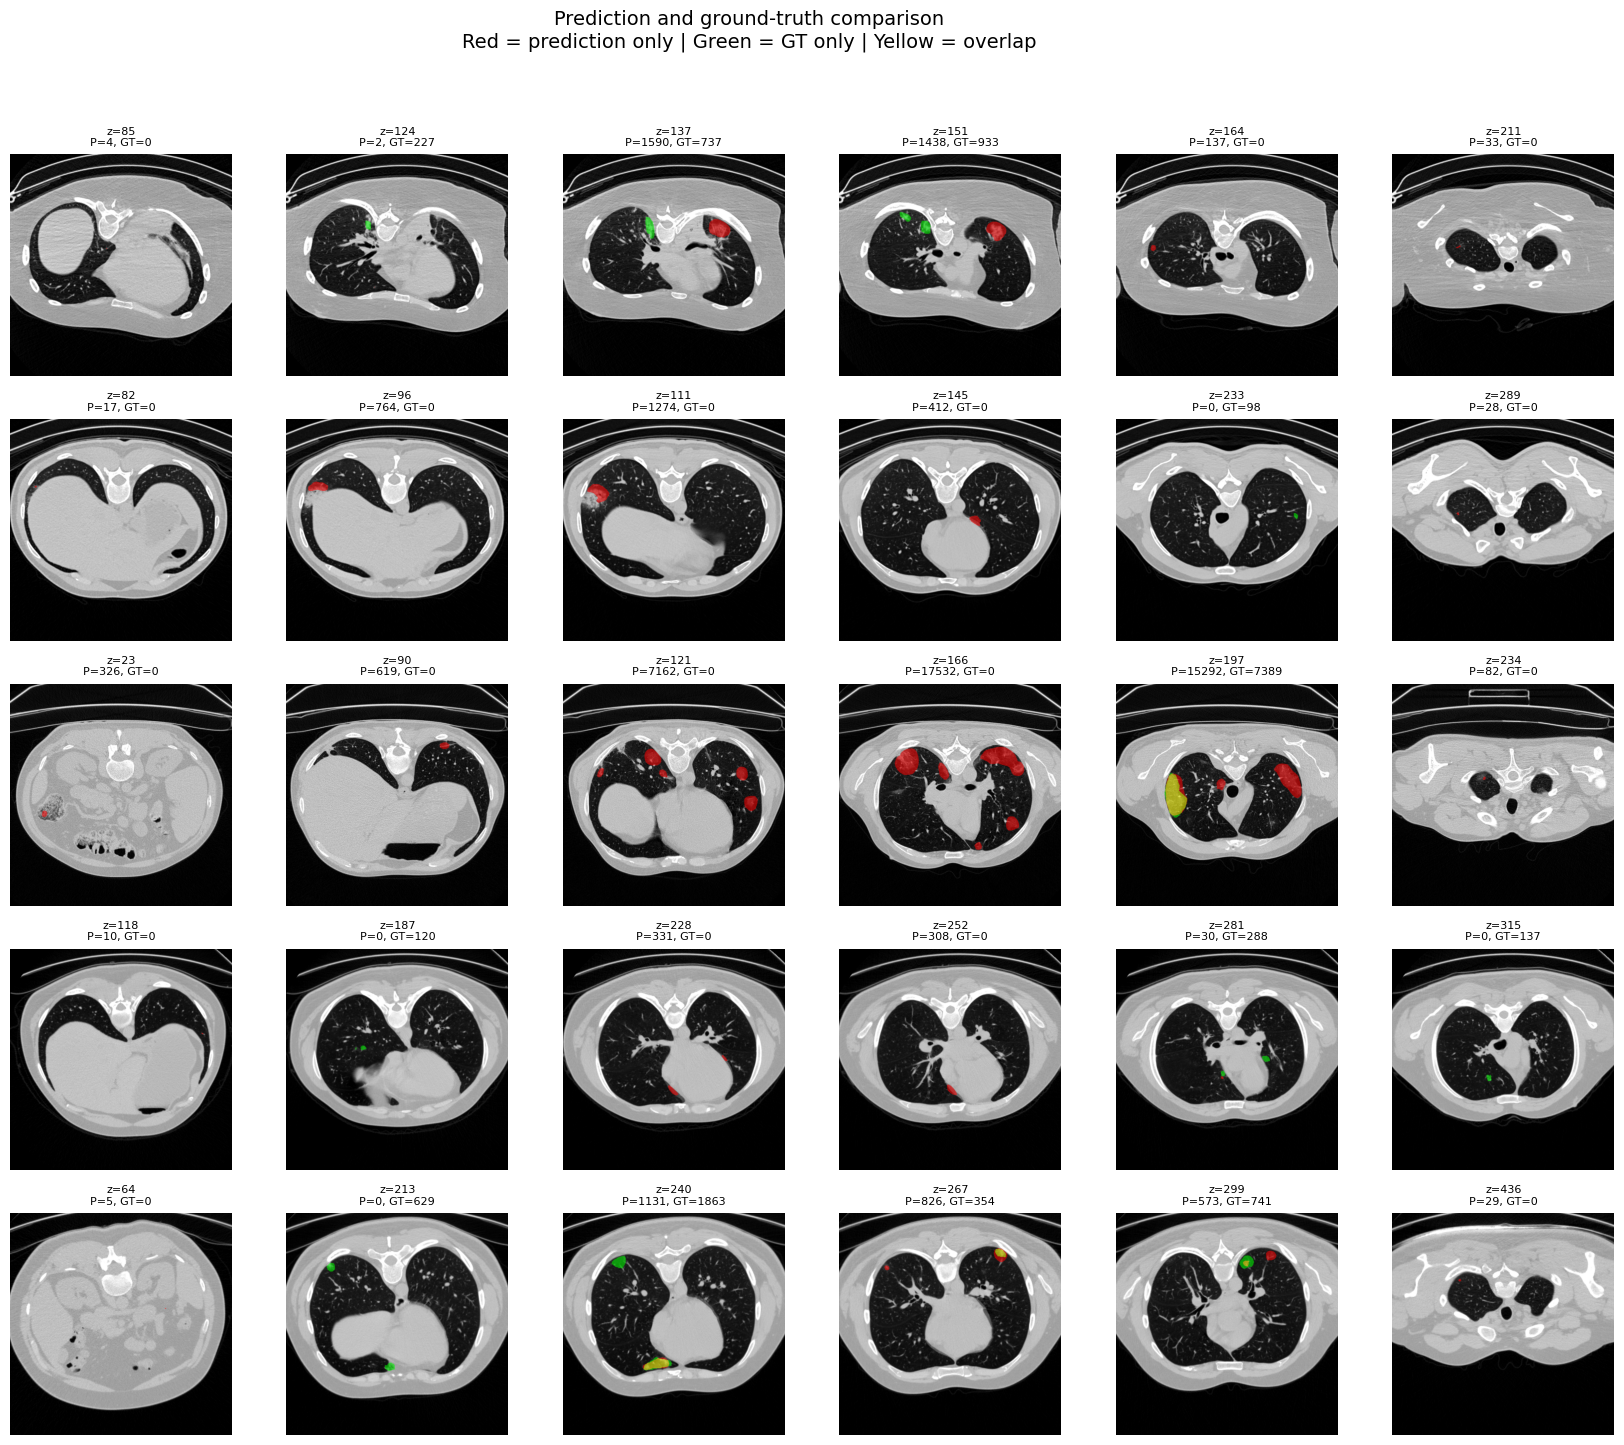

In [49]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from pathlib import Path


def show_multiple_cases_compact(
    cases,
    n_slices=6,
    hu_window=(-1000, 400),
    pred_threshold=0.5,
):
    """
    Compact visualization:
        one row per case
        red   = prediction
        green = ground truth
        yellow = overlap
    """

    loaded_cases = []

    for case in cases:
        ct = nib.load(str(case["ct_path"])).get_fdata()
        pred = nib.load(str(case["pred_path"])).get_fdata()

        gt = None
        if case.get("gt_path") is not None:
            gt = nib.load(str(case["gt_path"])).get_fdata()

        pred = pred >= pred_threshold

        if gt is not None:
            gt = gt > 0

        # Use both prediction and GT to select useful slices
        if gt is not None:
            foreground = np.logical_or(pred, gt)
        else:
            foreground = pred

        slice_scores = foreground.sum(axis=(0, 1))
        positive_slices = np.where(slice_scores > 0)[0]

        if len(positive_slices) == 0:
            selected_slices = np.linspace(
                0,
                ct.shape[2] - 1,
                n_slices,
                dtype=int,
            )
        else:
            # Spread selected slices through the positive range
            positions = np.linspace(
                0,
                len(positive_slices) - 1,
                n_slices,
                dtype=int,
            )
            selected_slices = positive_slices[positions]

        loaded_cases.append({
            "name": case["name"],
            "ct": ct,
            "pred": pred,
            "gt": gt,
            "slices": selected_slices,
        })

    if not loaded_cases:
        print("No cases available.")
        return

    nrows = len(loaded_cases)
    ncols = n_slices

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 3, nrows * 3),
        squeeze=False,
    )

    hu_min, hu_max = hu_window

    for row, case in enumerate(loaded_cases):
        for col, z in enumerate(case["slices"]):
            ax = axes[row, col]

            ct_slice = np.clip(
                case["ct"][:, :, z],
                hu_min,
                hu_max,
            )

            ct_norm = (
                ct_slice - hu_min
            ) / (
                hu_max - hu_min
            )

            # Convert grayscale CT to RGB
            rgb = np.stack(
                [ct_norm, ct_norm, ct_norm],
                axis=-1,
            )

            pred_slice = case["pred"][:, :, z]

            if case["gt"] is not None:
                gt_slice = case["gt"][:, :, z]

                pred_only = pred_slice & ~gt_slice
                gt_only = gt_slice & ~pred_slice
                overlap = pred_slice & gt_slice

                alpha = 0.55

                # Prediction only = red
                rgb[pred_only] = (
                    (1 - alpha) * rgb[pred_only]
                    + alpha * np.array([1, 0, 0])
                )

                # GT only = green
                rgb[gt_only] = (
                    (1 - alpha) * rgb[gt_only]
                    + alpha * np.array([0, 1, 0])
                )

                # Overlap = yellow
                rgb[overlap] = (
                    (1 - alpha) * rgb[overlap]
                    + alpha * np.array([1, 1, 0])
                )

                pred_voxels = int(pred_slice.sum())
                gt_voxels = int(gt_slice.sum())

                title = (
                    f"z={z}\n"
                    f"P={pred_voxels}, GT={gt_voxels}"
                )

            else:
                alpha = 0.55

                rgb[pred_slice] = (
                    (1 - alpha) * rgb[pred_slice]
                    + alpha * np.array([1, 0, 0])
                )

                title = (
                    f"z={z}\n"
                    f"P={int(pred_slice.sum())}"
                )

            ax.imshow(
                rgb.transpose(1, 0, 2),
                origin="lower",
            )

            ax.set_title(title, fontsize=8)
            ax.axis("off")

        axes[row, 0].set_ylabel(
            case["name"],
            fontsize=9,
            rotation=0,
            labelpad=70,
            va="center",
        )

    fig.suptitle(
        "Prediction and ground-truth comparison\n"
        "Red = prediction only | Green = GT only | Yellow = overlap",
        fontsize=14,
    )

    plt.tight_layout(
        rect=[0.07, 0.02, 1, 0.95]
    )

    plt.show()

    pred_dir = Path(
    INFER_PP_OUTPUT if pp_pkl else INFER_OUTPUT_FOLDER
)

preds = sorted(pred_dir.glob("*.nii.gz"))

cases = []

for pred_file in preds:
    case_id = pred_file.name.replace(".nii.gz", "")

    ct_file = images_ts / f"{case_id}_0000.nii.gz"
    gt_file = TEST_LABELS_DIR / f"{case_id}.nii.gz"

    if not ct_file.exists():
        continue

    cases.append({
        "name": case_id,
        "ct_path": ct_file,
        "pred_path": pred_file,
        "gt_path": gt_file if gt_file.exists() else None,
    })

    if len(cases) >= 5:
        break


show_multiple_cases_compact(
    cases=cases,
    n_slices=6,
    hu_window=(-1000, 400),
)

## 9. Export and portability

In [ ]:
# Pack the trained model into a zip for transfer or sharing.
# This exports only the folds that actually exist for the selected configuration.
import subprocess

MODEL_ZIP = os.path.join(NNUNET_RESULTS, f"{DATASET_FULL_NAME}_model.zip")
trainer_root = pathlib.Path(NNUNET_RESULTS) / DATASET_FULL_NAME / f"nnUNetTrainer__nnUNetPlans__{CONFIGURATION}"
completed_folds = sorted(
    int(p.parent.name.split("_")[-1])
    for p in trainer_root.glob("fold_*/checkpoint_final.pth")
)

if completed_folds:
    export_cmd = [
        "nnUNetv2_export_model_to_zip",
        "-d", str(DATASET_ID),
        "-o", MODEL_ZIP,
        "-c", CONFIGURATION,
        "-f", *[str(fold) for fold in completed_folds],
    ]
    if len(completed_folds) < N_FOLDS:
        export_cmd.append("--not_strict")
        print(f"Warning: only exporting completed folds {completed_folds} of {N_FOLDS}.")
        print("Train the remaining folds if you want a complete checkpoint set in the zip.")

    subprocess.run(export_cmd, check=True)
    print("Model exported to:", MODEL_ZIP)
else:
    print(f"No checkpoint_final.pth found for {CONFIGURATION}; skipping model export.")

Train the remaining folds if you want a complete checkpoint set in the zip.
Configuration 3d_fullres
Exporting fold_3
Exporting fold_4
No ensemble directory found for task 100
Model exported to: /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO_model.zip


In [ ]:
# On the target machine, install with:
# !nnUNetv2_install_pretrained_model_from_zip "{MODEL_ZIP}"
print(f"To install on another machine:\n"
      f"  nnUNetv2_install_pretrained_model_from_zip {MODEL_ZIP}")

To install on another machine:
  nnUNetv2_install_pretrained_model_from_zip /home/chest_ct/code/models/nnu-net/storage/nnUNet_results/Dataset100_GGO_model.zip


---
## Appendix: Common issues

| Issue | Fix |
|---|---|
| `nnUNet_raw not set` | Re-run cell 1 (sets `os.environ` for this kernel) |
| `dataset.json` errors | Re-run the `generate_dataset_json` cell |
| CUDA OOM during training | Reduce `nnUNet_n_proc_DA` or use `--c 3d_lowres` |
| NaN loss | Check CT values — extreme HU outliers can destabilise normalisation; clip to [-1024, 3071] before conversion |
| Very low Dice on GGO | GGO is subtle and diffuse; try ensembling 3d_fullres + 2d, and consider a lower `foreground_threshold` in postprocessing |
| Mask shape mismatch | Confirm the segmentation is `F×H×W×D` not transposed — adjust `extract_ggo_mask` indexing if needed |
| Variable voxel spacing | nnU-Net handles this automatically via anisotropic resampling; check spacing in the fingerprint |
